<a href="https://colab.research.google.com/github/yurii-kit10/Sales-and-Profit-Analysis/blob/main/Sales_and_Profit_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Аналіз продажів і прибутку

Python · Pandas · Matplotlib · Seaborn

Період даних: **01.01.2010–23.07.2017**.

## 1. Мета та питання дослідження

Дослідити продажі: порівняти категорії товарів, регіони й канали, розглянути час до відправлення та зміни продажів у часі.

- Які категорії мають найбільший дохід, прибуток і кількість проданих одиниць?
- Як відрізняються фінансові показники за регіонами та каналами?
- Скільки часу минає від замовлення до відправлення та чи видно його зв’язок із прибутком?
- Як змінюються продажі за роками та днями тижня?


## 2. Дані та завантаження

Працюю з трьома CSV-файлами: `events.csv`, `products.csv` і `countries.csv`.
Спочатку переглядаю їхній розмір, стовпці, типи даних і перші рядки.

Для завантаження даних підключаю Google Диск і відкриваю папку з трьома CSV-файлами. Далі виконую комірки зверху вниз.


In [319]:
from google.colab import drive
drive.mount("/content/drive")

%cd "/content/drive/MyDrive/Road/_Product_Analyst/6) Python for Data Analytics/7) Exploratory Data Analysis/Work folder"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/Road/_Product_Analyst/6) Python for Data Analytics/7) Exploratory Data Analysis/Work folder


In [320]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [321]:
# Єдині кольори й оформлення графіків
from matplotlib.ticker import FuncFormatter

colors = [
    "#7A6F9B", "#69A6A1", "#D99A6C", "#B76D84", "#8A9A5B", "#6B8FA3",
    "#AD9CC3", "#4E807A", "#B9784A", "#CF9AA8", "#AAB67D", "#9FBBCB"
]
sns.set_theme(style="white", palette=colors, font="DejaVu Sans")
plt.rcParams.update({
    "axes.titlesize": 14,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.facecolor": "white"
})


### 2.1. Замовлення — events


In [322]:
events = pd.read_csv("events.csv")


In [323]:
events.head()

,Order ID,Order Date,Ship Date,Order Priority,Country Code,Product ID,Sales Channel,Units Sold,Unit Price,Unit Cost
0,100640618,10/8/2014,10/18/2014,M,NOR,2103,Online,650.0,205.70,117.11
1,100983083,8/11/2016,8/11/2016,C,SRB,2103,Offline,1993.0,205.70,117.11
2,101025998,7/18/2014,8/11/2014,M,NaN,7940,Online,4693.0,668.27,502.54
3,102230632,5/13/2017,6/13/2017,L,MNE,2455,Online,1171.0,109.28,35.84
4,103435266,8/11/2012,9/18/2012,H,SRB,1270,Offline,7648.0,47.45,31.79


In [324]:
print(events.shape)

(1330, 10)


In [325]:
events.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1330 entries, 0 to 1329
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Order ID        1330 non-null   int64  
 1   Order Date      1330 non-null   object 
 2   Ship Date       1330 non-null   object 
 3   Order Priority  1330 non-null   object 
 4   Country Code    1248 non-null   object 
 5   Product ID      1330 non-null   int64  
 6   Sales Channel   1330 non-null   object 
 7   Units Sold      1328 non-null   float64
 8   Unit Price      1330 non-null   float64
 9   Unit Cost       1330 non-null   float64
dtypes: float64(3), int64(2), object(5)
memory usage: 104.0+ KB


In [326]:
events.columns

Index(['Order ID', 'Order Date', 'Ship Date', 'Order Priority', 'Country Code',
       'Product ID', 'Sales Channel', 'Units Sold', 'Unit Price', 'Unit Cost'],
      dtype='object')

Таблиця `events` містить **1 330 рядків і 10 стовпців**: номер замовлення, дати замовлення й відправлення, пріоритет, код країни, номер товару, канал продажу, кількість одиниць, ціну та собівартість одиниці.

Для приєднання довідників використовую `Product ID` і `Country Code`.


### 2.2. Категорії товарів — products


In [327]:
products = pd.read_csv("products.csv")


In [328]:
products.head()

,id,item_type
0,2103,Cereal
1,7940,Household
2,2455,Clothes
3,1270,Beverages
4,8681,Office Supplies


In [329]:
print(products.shape)

(12, 2)


In [330]:
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   id         12 non-null     int64 
 1   item_type  12 non-null     object
dtypes: int64(1), object(1)
memory usage: 324.0+ bytes


In [331]:
products.columns

Index(['id', 'item_type'], dtype='object')

У таблиці `products` є **12 категорій товарів**. Поле `id` відповідає `Product ID` у замовленнях, а `item_type` містить назву категорії.


### 2.3. Довідник країн — countries


In [332]:
countries = pd.read_csv("countries.csv")


In [333]:
countries.head()

,name,alpha-2,alpha-3,region,sub-region
0,Afghanistan,AF,AFG,Asia,Southern Asia
1,Åland Islands,AX,ALA,Europe,Northern Europe
2,Albania,AL,ALB,Europe,Southern Europe
3,Algeria,DZ,DZA,Africa,Northern Africa
4,American Samoa,AS,ASM,Oceania,Polynesia


In [334]:
countries.shape

(249, 5)

In [335]:
countries.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 249 entries, 0 to 248
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   name        249 non-null    object
 1   alpha-2     248 non-null    object
 2   alpha-3     249 non-null    object
 3   region      248 non-null    object
 4   sub-region  248 non-null    object
dtypes: object(5)
memory usage: 9.9+ KB


In [336]:
countries.columns

Index(['name', 'alpha-2', 'alpha-3', 'region', 'sub-region'], dtype='object')

Таблиця `countries` містить **249 рядків**: назву країни, дво- та трилітерний коди, регіон і субрегіон. Для об’єднання із замовленнями використовую `alpha-3`.


## 3. Підготовка даних


### 3.1. Пропуски в замовленнях

Перевіряю пропуски в `Country Code` і `Units Sold`, виконую їх обробку та повторно переглядаю таблицю.


In [337]:
events.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1330 entries, 0 to 1329
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Order ID        1330 non-null   int64  
 1   Order Date      1330 non-null   object 
 2   Ship Date       1330 non-null   object 
 3   Order Priority  1330 non-null   object 
 4   Country Code    1248 non-null   object 
 5   Product ID      1330 non-null   int64  
 6   Sales Channel   1330 non-null   object 
 7   Units Sold      1328 non-null   float64
 8   Unit Price      1330 non-null   float64
 9   Unit Cost       1330 non-null   float64
dtypes: float64(3), int64(2), object(5)
memory usage: 104.0+ KB


In [338]:
print(events.isna().sum())

Order ID           0
Order Date         0
Ship Date          0
Order Priority     0
Country Code      82
Product ID         0
Sales Channel      0
Units Sold         2
Unit Price         0
Unit Cost          0
dtype: int64


In [339]:
print(events.isna().sum() / events.shape[0] * 100)

Order ID          0.000000
Order Date        0.000000
Ship Date         0.000000
Order Priority    0.000000
Country Code      6.165414
Product ID        0.000000
Sales Channel     0.000000
Units Sold        0.150376
Unit Price        0.000000
Unit Cost         0.000000
dtype: float64


In [340]:
print(events.loc[events["Country Code"].isna()])

       Order ID Order Date  Ship Date Order Priority Country Code  Product ID  \
2     101025998  7/18/2014  8/11/2014              M          NaN        7940   
13    104548490   1/1/2014   1/5/2014              M          NaN        7331   
26    117929494  1/24/2015   3/2/2015              H          NaN        4594   
29    118859469   6/2/2011   7/1/2011              L          NaN        8969   
43    126948583  5/24/2017   7/9/2017              C          NaN        7331   
...         ...        ...        ...            ...          ...         ...   
1213  919922006  8/27/2011  9/18/2011              L          NaN        4594   
1220  922564303  3/17/2017   4/2/2017              L          NaN        7940   
1250  941061675   3/8/2017  3/20/2017              M          NaN        5988   
1296  975080668  7/23/2017  8/20/2017              C          NaN        5988   
1317  989102828  6/11/2012   7/8/2012              L          NaN        4594   

     Sales Channel  Units S

In [341]:
print(events.loc[events["Units Sold"].isna()])

      Order ID Order Date  Ship Date Order Priority Country Code  Product ID  \
183  217165648  5/20/2014   6/8/2014              M          ESP        8875   
319  309655511   5/5/2014  5/21/2014              C          HRV        3127   

    Sales Channel  Units Sold  Unit Price  Unit Cost  
183       Offline         NaN      421.89     364.69  
319       Offline         NaN       81.73      56.67  


In [342]:
events["Country Code"] = events["Country Code"].combine_first(countries["alpha-3"])
events.head()


,Order ID,Order Date,Ship Date,Order Priority,Country Code,Product ID,Sales Channel,Units Sold,Unit Price,Unit Cost
0,100640618,10/8/2014,10/18/2014,M,NOR,2103,Online,650.0,205.70,117.11
1,100983083,8/11/2016,8/11/2016,C,SRB,2103,Offline,1993.0,205.70,117.11
2,101025998,7/18/2014,8/11/2014,M,ALB,7940,Online,4693.0,668.27,502.54
3,102230632,5/13/2017,6/13/2017,L,MNE,2455,Online,1171.0,109.28,35.84
4,103435266,8/11/2012,9/18/2012,H,SRB,1270,Offline,7648.0,47.45,31.79


In [343]:
print(events.isna().sum())

Order ID           0
Order Date         0
Ship Date          0
Order Priority     0
Country Code      63
Product ID         0
Sales Channel      0
Units Sold         2
Unit Price         0
Unit Cost          0
dtype: int64


In [344]:
print(events.isna().sum() / events.shape[0] * 100)

Order ID          0.000000
Order Date        0.000000
Ship Date         0.000000
Order Priority    0.000000
Country Code      4.736842
Product ID        0.000000
Sales Channel     0.000000
Units Sold        0.150376
Unit Price        0.000000
Unit Cost         0.000000
dtype: float64


In [345]:
events["Country Code"] = events["Country Code"].fillna("Unknown")
events = events.dropna(subset=["Units Sold"])
events.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1328 entries, 0 to 1329
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Order ID        1328 non-null   int64  
 1   Order Date      1328 non-null   object 
 2   Ship Date       1328 non-null   object 
 3   Order Priority  1328 non-null   object 
 4   Country Code    1328 non-null   object 
 5   Product ID      1328 non-null   int64  
 6   Sales Channel   1328 non-null   object 
 7   Units Sold      1328 non-null   float64
 8   Unit Price      1328 non-null   float64
 9   Unit Cost       1328 non-null   float64
dtypes: float64(3), int64(2), object(5)
memory usage: 114.1+ KB


Після обробки позначив невідомі коди країн як `Unknown`. Видалив **2 рядки** без кількості проданих одиниць: вона потрібна для розрахунку доходу й прибутку. У робочій таблиці залишилося **1 328 замовлень**.


### 3.2. Пропуски в довіднику товарів


In [346]:
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   id         12 non-null     int64 
 1   item_type  12 non-null     object
dtypes: int64(1), object(1)
memory usage: 324.0+ bytes


In [347]:
print(products.isna().sum())

id           0
item_type    0
dtype: int64


У таблиці `products` пропущених значень немає.


### 3.3. Пропуски в довіднику країн


In [348]:
countries.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 249 entries, 0 to 248
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   name        249 non-null    object
 1   alpha-2     248 non-null    object
 2   alpha-3     249 non-null    object
 3   region      248 non-null    object
 4   sub-region  248 non-null    object
dtypes: object(5)
memory usage: 9.9+ KB


In [349]:
print(countries.isna().sum())

name          0
alpha-2       1
alpha-3       0
region        1
sub-region    1
dtype: int64


In [350]:
print(countries.isna().sum() / countries.shape[0] * 100)

name          0.000000
alpha-2       0.401606
alpha-3       0.000000
region        0.401606
sub-region    0.401606
dtype: float64


In [351]:
print(countries.loc[countries["alpha-2"].isna()])

        name alpha-2 alpha-3  region          sub-region
153  Namibia     NaN     NAM  Africa  Sub-Saharan Africa


In [352]:
print(countries.loc[countries["region"].isna()])

         name alpha-2 alpha-3 region sub-region
8  Antarctica      AQ     ATA    NaN        NaN


In [353]:
print(countries.loc[countries["sub-region"].isna()])

         name alpha-2 alpha-3 region sub-region
8  Antarctica      AQ     ATA    NaN        NaN


In [354]:
unique_countries = countries["name"].value_counts()
unique_countries.head(10)

,count
name,
Afghanistan,1
Åland Islands,1
Albania,1
Algeria,1
American Samoa,1
Andorra,1
Angola,1
Anguilla,1
Antarctica,1


У довіднику для Antarctica не заповнені регіон і субрегіон. Залишаю ці значення без змін.


In [355]:
countries.loc[countries["name"] == "Namibia", "alpha-2"] = "NA"
countries.loc[countries["name"] == "Namibia"]

,name,alpha-2,alpha-3,region,sub-region
153,Namibia,NA,NAM,Africa,Sub-Saharan Africa


In [356]:
countries.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 249 entries, 0 to 248
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   name        249 non-null    object
 1   alpha-2     249 non-null    object
 2   alpha-3     249 non-null    object
 3   region      248 non-null    object
 4   sub-region  248 non-null    object
dtypes: object(5)
memory usage: 9.9+ KB


Для Namibia вказав дволітерний код `NA`.


## 4. Перевірка типів і узгодженості


### 4.1. Замовлення

Перевіряю дати, дублікати й текстові значення. Окремо дивлюся, чи не передує відправлення замовленню та чи не перевищує собівартість ціну.


In [357]:
events.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1328 entries, 0 to 1329
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Order ID        1328 non-null   int64  
 1   Order Date      1328 non-null   object 
 2   Ship Date       1328 non-null   object 
 3   Order Priority  1328 non-null   object 
 4   Country Code    1328 non-null   object 
 5   Product ID      1328 non-null   int64  
 6   Sales Channel   1328 non-null   object 
 7   Units Sold      1328 non-null   float64
 8   Unit Price      1328 non-null   float64
 9   Unit Cost       1328 non-null   float64
dtypes: float64(3), int64(2), object(5)
memory usage: 114.1+ KB


In [358]:
events.head()

,Order ID,Order Date,Ship Date,Order Priority,Country Code,Product ID,Sales Channel,Units Sold,Unit Price,Unit Cost
0,100640618,10/8/2014,10/18/2014,M,NOR,2103,Online,650.0,205.70,117.11
1,100983083,8/11/2016,8/11/2016,C,SRB,2103,Offline,1993.0,205.70,117.11
2,101025998,7/18/2014,8/11/2014,M,ALB,7940,Online,4693.0,668.27,502.54
3,102230632,5/13/2017,6/13/2017,L,MNE,2455,Online,1171.0,109.28,35.84
4,103435266,8/11/2012,9/18/2012,H,SRB,1270,Offline,7648.0,47.45,31.79


In [359]:
events["Order Date"] = pd.to_datetime(events["Order Date"])
events["Ship Date"] = pd.to_datetime(events["Ship Date"])
events.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1328 entries, 0 to 1329
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Order ID        1328 non-null   int64         
 1   Order Date      1328 non-null   datetime64[ns]
 2   Ship Date       1328 non-null   datetime64[ns]
 3   Order Priority  1328 non-null   object        
 4   Country Code    1328 non-null   object        
 5   Product ID      1328 non-null   int64         
 6   Sales Channel   1328 non-null   object        
 7   Units Sold      1328 non-null   float64       
 8   Unit Price      1328 non-null   float64       
 9   Unit Cost       1328 non-null   float64       
dtypes: datetime64[ns](2), float64(3), int64(2), object(3)
memory usage: 146.4+ KB


Перетворив `Order Date` і `Ship Date` на дати, щоб надалі працювати з роками та часом до відправлення.


In [360]:
events.duplicated().sum()

np.int64(0)

In [361]:
events.duplicated(subset="Order ID").sum()

np.int64(0)

In [362]:
events["Order Priority"].value_counts()

,count
Order Priority,
M,352
H,335
L,334
C,304
C,2
M,1


In [363]:
events["Order Priority"] = events["Order Priority"].str.strip().str.upper()
events["Order Priority"].value_counts()

,count
Order Priority,
M,353
H,335
L,334
C,306


In [364]:
events["Country Code"].value_counts()

,count
Country Code,
Unknown,63
SMR,40
AND,40
ROU,34
UKR,33
...,...
SAU,1
ARE,1
VNM,1


In [365]:
events["Sales Channel"].value_counts()

,count
Sales Channel,
Offline,665
Online,660
online,3


In [366]:
events["Sales Channel"] = events["Sales Channel"].str.strip().str.title()
events["Sales Channel"].value_counts()

,count
Sales Channel,
Offline,665
Online,663


Повних дублікатів і повторів `Order ID` немає. Прибрав зайві пробіли та узгодив написання пріоритетів замовлень і каналів продажу.


In [367]:
events.describe()

,Order ID,Order Date,Ship Date,Product ID,Units Sold,Unit Price,Unit Cost
count,1.328000e+03,1328,1328,1328.000000,1328.000000,1328.000000,1328.000000
mean,5.416231e+08,2013-10-11 22:28:54.939759104,2013-11-05 17:22:02.891566336,5787.775602,4952.201807,264.913245,187.211521
min,1.006406e+08,2010-01-01 00:00:00,2010-01-10 00:00:00,1270.000000,2.000000,9.330000,6.920000
25%,3.213291e+08,2011-12-14 06:00:00,2012-01-02 00:00:00,3127.000000,2356.750000,81.730000,35.840000
50%,5.399925e+08,2013-10-15 12:00:00,2013-11-05 12:00:00,5988.000000,4962.000000,154.060000,97.440000
75%,7.547357e+08,2015-08-29 12:00:00,2015-10-04 18:00:00,8681.000000,7459.500000,437.200000,263.330000
max,9.998797e+08,2017-07-23 00:00:00,2017-08-31 00:00:00,8969.000000,9999.000000,668.270000,524.960000
std,2.573496e+08,NaN,NaN,2820.635702,2905.198996,217.386320,176.187801


In [368]:
(events["Ship Date"] < events["Order Date"]).sum()

np.int64(0)

In [369]:
(events["Unit Cost"] > events["Unit Price"]).sum()

np.int64(0)

У перевірених рядках відправлення не передує замовленню, а собівартість одиниці не перевищує її ціну.


### 4.2. Товари


In [370]:
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   id         12 non-null     int64 
 1   item_type  12 non-null     object
dtypes: int64(1), object(1)
memory usage: 324.0+ bytes


In [371]:
products.head()

,id,item_type
0,2103,Cereal
1,7940,Household
2,2455,Clothes
3,1270,Beverages
4,8681,Office Supplies


In [372]:
products.duplicated().sum()

np.int64(0)

In [373]:
products.duplicated(subset="id").sum()

np.int64(0)

In [374]:
products["item_type"].value_counts().sort_index()

,count
item_type,
Baby Food,1
Beverages,1
Cereal,1
Clothes,1
Cosmetics,1
Fruits,1
Household,1
Meat,1
Office Supplies,1


У довіднику товарів немає повних дублікатів і повторів `id`. Переглянув назви категорій.


### 4.3. Країни


In [375]:
countries.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 249 entries, 0 to 248
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   name        249 non-null    object
 1   alpha-2     249 non-null    object
 2   alpha-3     249 non-null    object
 3   region      248 non-null    object
 4   sub-region  248 non-null    object
dtypes: object(5)
memory usage: 9.9+ KB


In [376]:
countries.head()

,name,alpha-2,alpha-3,region,sub-region
0,Afghanistan,AF,AFG,Asia,Southern Asia
1,Åland Islands,AX,ALA,Europe,Northern Europe
2,Albania,AL,ALB,Europe,Southern Europe
3,Algeria,DZ,DZA,Africa,Northern Africa
4,American Samoa,AS,ASM,Oceania,Polynesia


In [377]:
countries.duplicated().sum()

np.int64(0)

In [378]:
countries.duplicated(subset="name").sum()

np.int64(0)

In [379]:
countries.duplicated(subset="alpha-2").sum()

np.int64(0)

In [380]:
countries.duplicated(subset="alpha-3").sum()

np.int64(0)

In [381]:
countries["region"].value_counts()

,count
region,
Africa,60
Americas,57
Asia,51
Europe,51
Oceania,29


In [382]:
countries["sub-region"].value_counts().sort_index()

,count
sub-region,
Australia and New Zealand,6
Central Asia,5
Eastern Asia,8
Eastern Europe,10
Latin America and the Caribbean,52
Melanesia,5
Micronesia,8
Northern Africa,7
Northern America,5


У довіднику країн не виявив дублікатів рядків, назв і кодів країн.


## 5. Аналіз продажів


### 5.1. Об’єднання таблиць

До замовлень приєдную категорії товарів і довідник країн. Використовую `LEFT JOIN`, щоб зберегти рядки основної таблиці.


In [383]:
sales_data = events.merge(products, left_on="Product ID", right_on="id", how="left")
sales_data = sales_data.merge(countries, left_on="Country Code", right_on="alpha-3", how="left")
sales_data.head()

,Order ID,Order Date,Ship Date,Order Priority,Country Code,Product ID,Sales Channel,Units Sold,Unit Price,Unit Cost,id,item_type,name,alpha-2,alpha-3,region,sub-region
0,100640618,2014-10-08,2014-10-18,M,NOR,2103,Online,650.0,205.70,117.11,2103,Cereal,Norway,NO,NOR,Europe,Northern Europe
1,100983083,2016-08-11,2016-08-11,C,SRB,2103,Offline,1993.0,205.70,117.11,2103,Cereal,Serbia,RS,SRB,Europe,Southern Europe
2,101025998,2014-07-18,2014-08-11,M,ALB,7940,Online,4693.0,668.27,502.54,7940,Household,Albania,AL,ALB,Europe,Southern Europe
3,102230632,2017-05-13,2017-06-13,L,MNE,2455,Online,1171.0,109.28,35.84,2455,Clothes,Montenegro,ME,MNE,Europe,Southern Europe
4,103435266,2012-08-11,2012-09-18,H,SRB,1270,Offline,7648.0,47.45,31.79,1270,Beverages,Serbia,RS,SRB,Europe,Southern Europe


In [384]:
sales_data.shape

(1328, 17)

In [385]:
sales_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1328 entries, 0 to 1327
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Order ID        1328 non-null   int64         
 1   Order Date      1328 non-null   datetime64[ns]
 2   Ship Date       1328 non-null   datetime64[ns]
 3   Order Priority  1328 non-null   object        
 4   Country Code    1328 non-null   object        
 5   Product ID      1328 non-null   int64         
 6   Sales Channel   1328 non-null   object        
 7   Units Sold      1328 non-null   float64       
 8   Unit Price      1328 non-null   float64       
 9   Unit Cost       1328 non-null   float64       
 10  id              1328 non-null   int64         
 11  item_type       1328 non-null   object        
 12  name            1265 non-null   object        
 13  alpha-2         1265 non-null   object        
 14  alpha-3         1265 non-null   object        
 15  regi

In [386]:
sales_data.isna().sum()

,0
Order ID,0
Order Date,0
Ship Date,0
Order Priority,0
Country Code,0
Product ID,0
Sales Channel,0
Units Sold,0
Unit Price,0
Unit Cost,0


In [387]:
sales_data = sales_data.drop(columns=["alpha-2", "alpha-3", "id"])
sales_data.columns = sales_data.columns.str.lower().str.replace(" ", "_").str.replace("-", "_")
sales_data = sales_data.rename(columns={"name": "country_name"})
sales_data.head()

,order_id,order_date,ship_date,order_priority,country_code,product_id,sales_channel,units_sold,unit_price,unit_cost,item_type,country_name,region,sub_region
0,100640618,2014-10-08,2014-10-18,M,NOR,2103,Online,650.0,205.70,117.11,Cereal,Norway,Europe,Northern Europe
1,100983083,2016-08-11,2016-08-11,C,SRB,2103,Offline,1993.0,205.70,117.11,Cereal,Serbia,Europe,Southern Europe
2,101025998,2014-07-18,2014-08-11,M,ALB,7940,Online,4693.0,668.27,502.54,Household,Albania,Europe,Southern Europe
3,102230632,2017-05-13,2017-06-13,L,MNE,2455,Online,1171.0,109.28,35.84,Clothes,Montenegro,Europe,Southern Europe
4,103435266,2012-08-11,2012-09-18,H,SRB,1270,Offline,7648.0,47.45,31.79,Beverages,Serbia,Europe,Southern Europe


Створив таблицю `sales_data`. Прибрав зайві стовпці та записав їхні назви малими літерами з підкресленнями.


### 5.2. Основні показники

Рахую замовлення, прибуток, кількість назв країн у підготовленій таблиці та частки каналів продажу.
Прибуток визначаю як різницю між ціною й собівартістю одиниці, помножену на продану кількість.


In [388]:
sales_data.head()

,order_id,order_date,ship_date,order_priority,country_code,product_id,sales_channel,units_sold,unit_price,unit_cost,item_type,country_name,region,sub_region
0,100640618,2014-10-08,2014-10-18,M,NOR,2103,Online,650.0,205.70,117.11,Cereal,Norway,Europe,Northern Europe
1,100983083,2016-08-11,2016-08-11,C,SRB,2103,Offline,1993.0,205.70,117.11,Cereal,Serbia,Europe,Southern Europe
2,101025998,2014-07-18,2014-08-11,M,ALB,7940,Online,4693.0,668.27,502.54,Household,Albania,Europe,Southern Europe
3,102230632,2017-05-13,2017-06-13,L,MNE,2455,Online,1171.0,109.28,35.84,Clothes,Montenegro,Europe,Southern Europe
4,103435266,2012-08-11,2012-09-18,H,SRB,1270,Offline,7648.0,47.45,31.79,Beverages,Serbia,Europe,Southern Europe


In [389]:
sales_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1328 entries, 0 to 1327
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   order_id        1328 non-null   int64         
 1   order_date      1328 non-null   datetime64[ns]
 2   ship_date       1328 non-null   datetime64[ns]
 3   order_priority  1328 non-null   object        
 4   country_code    1328 non-null   object        
 5   product_id      1328 non-null   int64         
 6   sales_channel   1328 non-null   object        
 7   units_sold      1328 non-null   float64       
 8   unit_price      1328 non-null   float64       
 9   unit_cost       1328 non-null   float64       
 10  item_type       1328 non-null   object        
 11  country_name    1265 non-null   object        
 12  region          1265 non-null   object        
 13  sub_region      1265 non-null   object        
dtypes: datetime64[ns](2), float64(3), int64(2), object(7)
me

In [390]:
number_of_order = sales_data["order_id"].nunique()
print(number_of_order)

total_profit = ((sales_data["unit_price"]-sales_data["unit_cost"])*sales_data["units_sold"]).sum()
print(total_profit)

number_of_countries = sales_data["country_name"].nunique()
print(number_of_countries)

1328
501434459.0
60


In [391]:
popular_category = sales_data.groupby("item_type")["units_sold"].sum().sort_values(ascending=False)
print(popular_category)

online_share = (sales_data["sales_channel"]=="Online").sum()/len(sales_data) * 100
print(online_share)
offline_share = (sales_data["sales_channel"]=="Offline").sum()/len(sales_data) * 100
print(offline_share)

item_type
Office Supplies    617641.0
Beverages          613133.0
Fruits             591672.0
Clothes            591385.0
Vegetables         582544.0
Baby Food          562706.0
Personal Care      557678.0
Cosmetics          533291.0
Meat               530380.0
Snacks             490160.0
Cereal             465685.0
Household          440249.0
Name: units_sold, dtype: float64
49.924698795180724
50.075301204819276


- **1 328 замовлень** у робочій таблиці.
- **501,43 млн** розрахованого прибутку.
- **60 назв країн** у результаті об’єднання.
- **Office Supplies — 617 641 одиниця**, найбільше серед категорій.
- Частка замовлень **Online — 49,92%**, **Offline — 50,08%**. Кількість замовлень майже однакова.


### 5.3. Дохід, собівартість і прибуток за категоріями

Розраховую дохід як кількість одиниць, помножену на ціну. Собівартість — як кількість, помножену на собівартість одиниці. Порівнюю суми за категоріями товарів.


In [392]:
sales_data["revenue"] = sales_data["units_sold"] * sales_data["unit_price"]
sales_data["cost"] = sales_data["units_sold"] * sales_data["unit_cost"]
sales_data["profit"] = sales_data["revenue"] - sales_data["cost"]
sales_data.head()

,order_id,order_date,ship_date,order_priority,country_code,product_id,sales_channel,units_sold,unit_price,unit_cost,item_type,country_name,region,sub_region,revenue,cost,profit
0,100640618,2014-10-08,2014-10-18,M,NOR,2103,Online,650.0,205.70,117.11,Cereal,Norway,Europe,Northern Europe,133705.00,76121.50,57583.50
1,100983083,2016-08-11,2016-08-11,C,SRB,2103,Offline,1993.0,205.70,117.11,Cereal,Serbia,Europe,Southern Europe,409960.10,233400.23,176559.87
2,101025998,2014-07-18,2014-08-11,M,ALB,7940,Online,4693.0,668.27,502.54,Household,Albania,Europe,Southern Europe,3136191.11,2358420.22,777770.89
3,102230632,2017-05-13,2017-06-13,L,MNE,2455,Online,1171.0,109.28,35.84,Clothes,Montenegro,Europe,Southern Europe,127966.88,41968.64,85998.24
4,103435266,2012-08-11,2012-09-18,H,SRB,1270,Offline,7648.0,47.45,31.79,Beverages,Serbia,Europe,Southern Europe,362897.60,243129.92,119767.68


In [393]:
category_finance = sales_data.groupby("item_type")[["revenue", "cost", "profit"]].sum().reset_index()
category_finance = category_finance.sort_values(by="revenue", ascending=False)

In [394]:
category_finance_melted = category_finance.melt(id_vars="item_type", value_vars=["revenue", "cost", "profit"], var_name="metric", value_name="value")

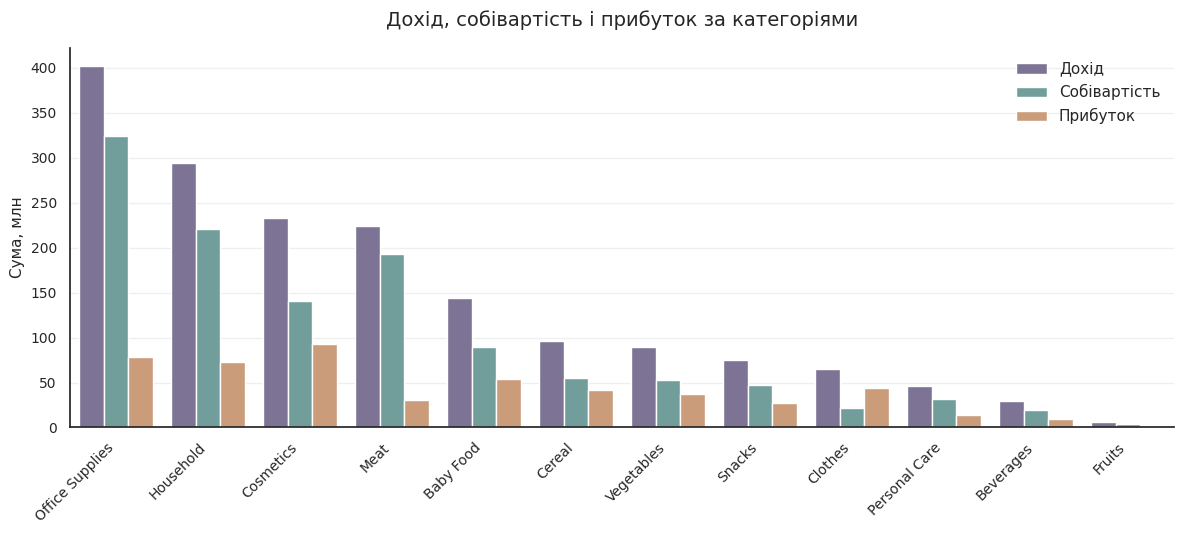

In [395]:
plt.figure(figsize=(12, 5.5))
sns.barplot(data=category_finance_melted, x="item_type", y="value", hue="metric")
plt.title('Дохід, собівартість і прибуток за категоріями', fontsize=14, pad=16)
plt.xlabel('')
plt.ylabel('Сума, млн')
plt.xticks(rotation=45, ha="right")
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda value, _: f"{value / 1_000_000:g}"))
plt.legend(handles=plt.gca().get_legend_handles_labels()[0], labels=["Дохід", "Собівартість", "Прибуток"], title="", frameon=False)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


**Office Supplies** має найбільший дохід і собівартість. За прибутком лідирує **Cosmetics**.


### 5.4. Кількість проданих одиниць за категоріями

Порівнюю загальну кількість проданих одиниць.


In [396]:
popular_category = sales_data.groupby("item_type")["units_sold"].sum().sort_values(ascending=False).reset_index()

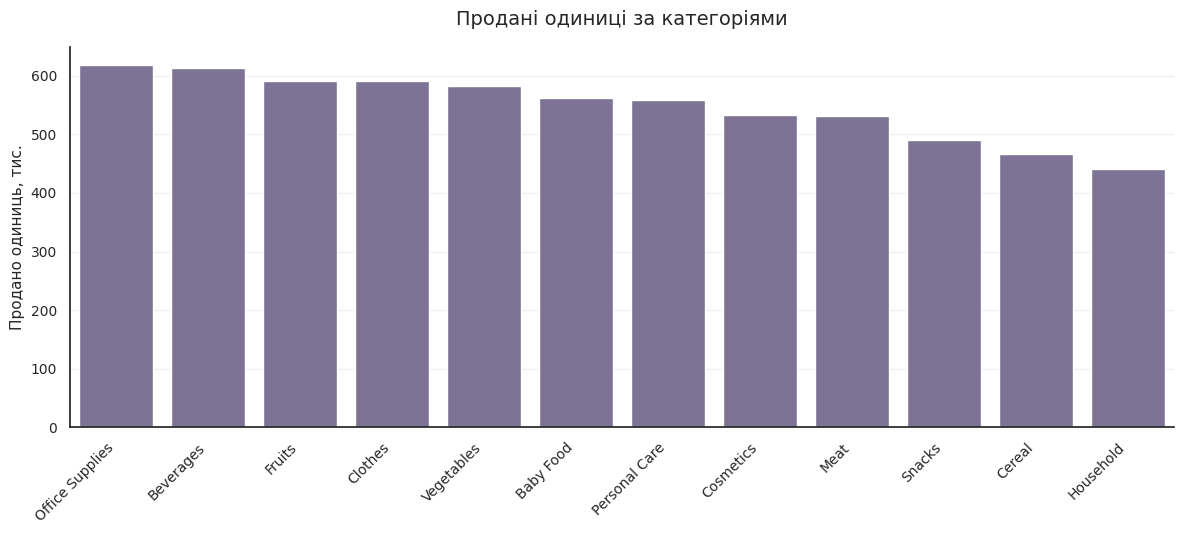

In [397]:
plt.figure(figsize=(12, 5.5))
sns.barplot(data=popular_category, x="item_type", y="units_sold", color="#7A6F9B")
plt.title('Продані одиниці за категоріями', fontsize=14, pad=16)
plt.xlabel('')
plt.ylabel('Продано одиниць, тис.')
plt.xticks(rotation=45, ha="right")
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda value, _: f"{value / 1_000:g}"))
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


За кількістю проданих одиниць лідирує **Office Supplies**. Високі значення також мають Beverages, Fruits, Clothes і Vegetables. Найменше одиниць продано в категорії Household.


### 5.5. Фінансові показники за регіонами


In [398]:
region_finance = sales_data.groupby("region")[["revenue", "cost", "profit"]].sum().reset_index()
region_finance = region_finance.sort_values(by="revenue", ascending=False)

In [399]:
region_finance_melted = region_finance.melt(id_vars="region", value_vars=["revenue", "cost", "profit"], var_name="metric", value_name="value")

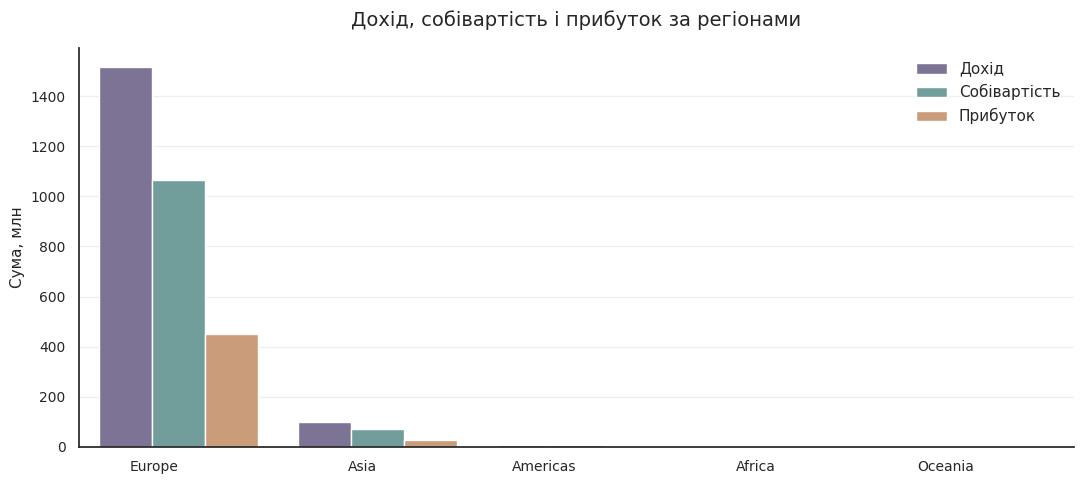

In [400]:
plt.figure(figsize=(11, 5))
sns.barplot(data=region_finance_melted, x="region", y="value", hue="metric")
plt.title('Дохід, собівартість і прибуток за регіонами', fontsize=14, pad=16)
plt.xlabel('')
plt.ylabel('Сума, млн')
plt.xticks(rotation=0, ha="right")
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda value, _: f"{value / 1_000_000:g}"))
plt.legend(handles=plt.gca().get_legend_handles_labels()[0], labels=["Дохід", "Собівартість", "Прибуток"], title="", frameon=False)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


У підготовленій таблиці **Europe** має найбільші суми доходу, собівартості й прибутку. Інші регіони дають значно менші суми.


### 5.6. Фінансові показники за каналами


In [401]:
channel_finance = sales_data.groupby("sales_channel")[["revenue", "cost", "profit"]].sum().reset_index()

In [402]:
channel_finance_melted = channel_finance.melt(id_vars="sales_channel", value_vars=["revenue", "cost", "profit"], var_name="metric", value_name="value")

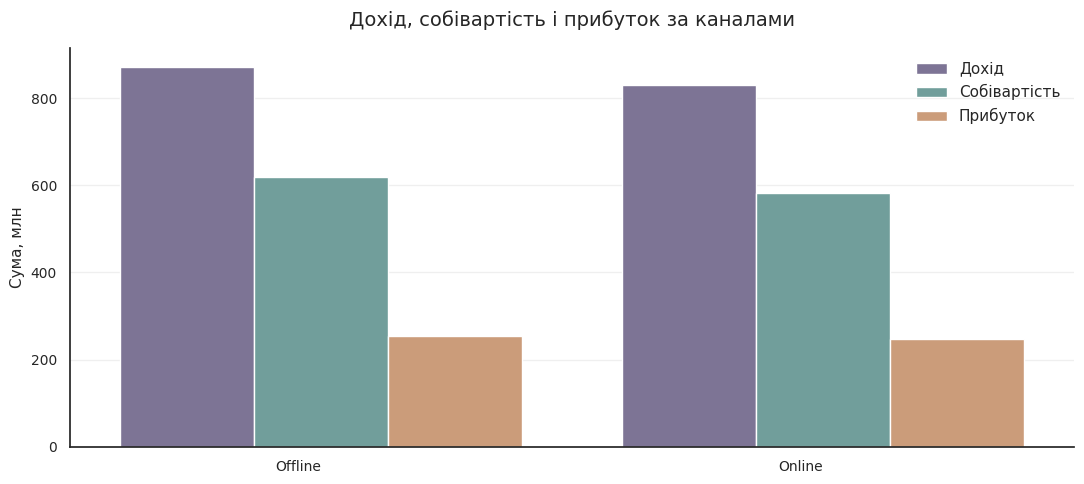

In [403]:
plt.figure(figsize=(11, 5))
sns.barplot(data=channel_finance_melted, x="sales_channel", y="value", hue="metric")
plt.title('Дохід, собівартість і прибуток за каналами', fontsize=14, pad=16)
plt.xlabel('')
plt.ylabel('Сума, млн')
plt.xticks(rotation=0, ha="right")
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda value, _: f"{value / 1_000_000:g}"))
plt.legend(handles=plt.gca().get_legend_handles_labels()[0], labels=["Дохід", "Собівартість", "Прибуток"], title="", frameon=False)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


**Offline** має трохи вищі фінансові показники, ніж Online. Водночас обидва канали дають близькі суми.


## 6. Час від замовлення до відправлення

Рахую кількість днів між `Order Date` і `Ship Date`. Порівнюю медіану за категоріями й регіонами: половина замовлень має час не більший за це значення.


In [404]:
sales_data["shipment_time"] = (sales_data["ship_date"] - sales_data["order_date"]).dt.days
sales_data.head()

,order_id,order_date,ship_date,order_priority,country_code,product_id,sales_channel,units_sold,unit_price,unit_cost,item_type,country_name,region,sub_region,revenue,cost,profit,shipment_time
0,100640618,2014-10-08,2014-10-18,M,NOR,2103,Online,650.0,205.70,117.11,Cereal,Norway,Europe,Northern Europe,133705.00,76121.50,57583.50,10
1,100983083,2016-08-11,2016-08-11,C,SRB,2103,Offline,1993.0,205.70,117.11,Cereal,Serbia,Europe,Southern Europe,409960.10,233400.23,176559.87,0
2,101025998,2014-07-18,2014-08-11,M,ALB,7940,Online,4693.0,668.27,502.54,Household,Albania,Europe,Southern Europe,3136191.11,2358420.22,777770.89,24
3,102230632,2017-05-13,2017-06-13,L,MNE,2455,Online,1171.0,109.28,35.84,Clothes,Montenegro,Europe,Southern Europe,127966.88,41968.64,85998.24,31
4,103435266,2012-08-11,2012-09-18,H,SRB,1270,Offline,7648.0,47.45,31.79,Beverages,Serbia,Europe,Southern Europe,362897.60,243129.92,119767.68,38


### 6.1. Категорії товарів


In [405]:
shipment_by_category = sales_data.groupby("item_type")["shipment_time"].median().sort_values(ascending=False).reset_index()

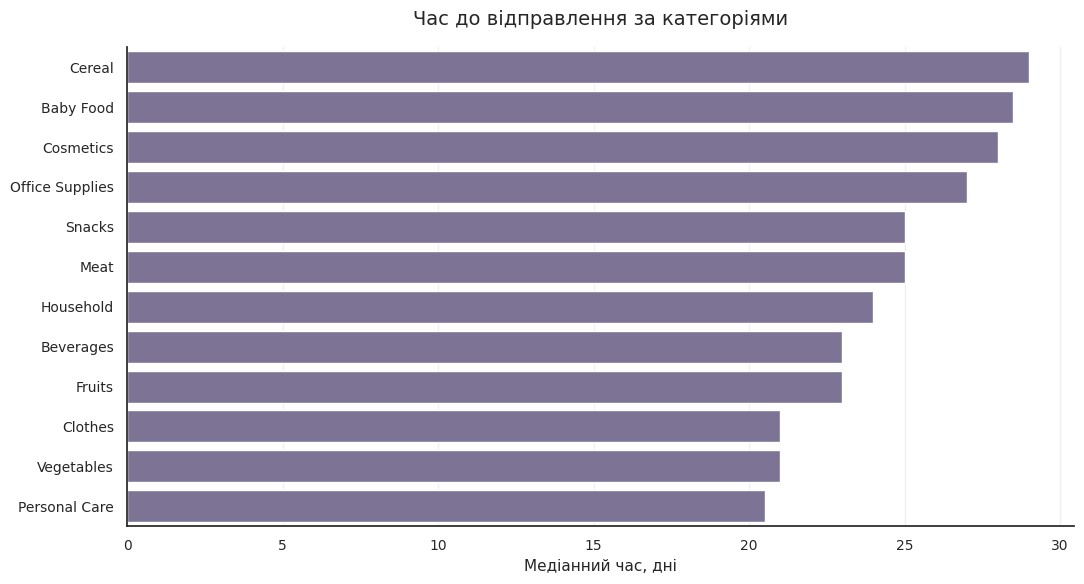

In [406]:
plt.figure(figsize=(11, 6))
sns.barplot(data=shipment_by_category, x="shipment_time", y="item_type", color="#7A6F9B")
plt.title('Час до відправлення за категоріями', fontsize=14, pad=16)
plt.xlabel('Медіанний час, дні')
plt.ylabel('')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()


Найдовший медіанний час до відправлення має **Cereal — 29 днів**. У Baby Food він становить 28,5 дня, у Cosmetics — 28 днів. Найкоротший показник у **Personal Care — 20,5 дня**.


### 6.2. Регіони


In [407]:
shipment_by_region = sales_data.groupby("region")["shipment_time"].median().sort_values(ascending=False).reset_index()

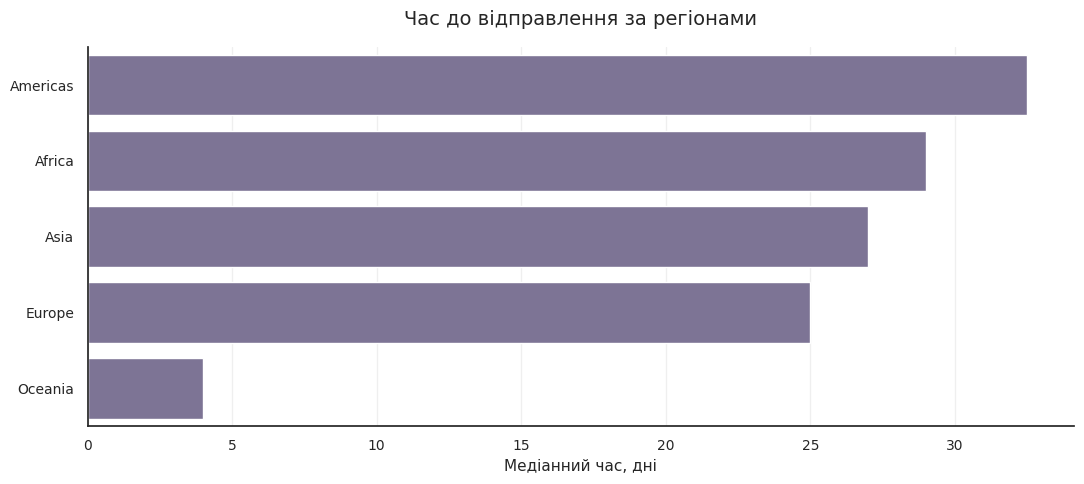

In [408]:
plt.figure(figsize=(11, 5))
sns.barplot(data=shipment_by_region, x="shipment_time", y="region", color="#7A6F9B")
plt.title('Час до відправлення за регіонами', fontsize=14, pad=16)
plt.xlabel('Медіанний час, дні')
plt.ylabel('')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()


Найдовший медіанний час до відправлення має **Americas — 32,5 дня**, найкоротший — **Oceania — 4 дні**. Значення Africa, Asia та Europe розташовані між ними.


### 6.3. Прибуток і час до відправлення

На точковому графіку порівнюю час до відправлення та прибуток кожного замовлення.


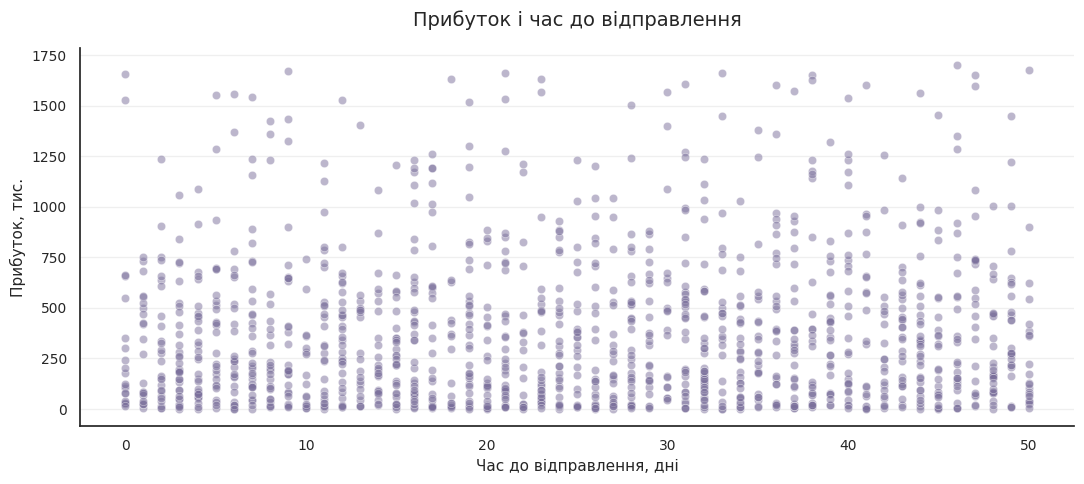

In [409]:
plt.figure(figsize=(11, 5))
sns.scatterplot(data=sales_data, x="shipment_time",y="profit", alpha=0.5, color="#7A6F9B")
plt.title('Прибуток і час до відправлення', fontsize=14, pad=16)
plt.xlabel('Час до відправлення, дні')
plt.ylabel('Прибуток, тис.')
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda value, _: f"{value / 1_000:g}"))
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


На графіку не видно чіткої залежності: замовлення з різним прибутком трапляються і за короткого, і за довгого часу до відправлення.


## 7. Динаміка продажів

Порівнюю дохід за роками та кількість проданих одиниць за днями тижня. Дані охоплюють **01.01.2010–23.07.2017**; останній рік представлений частково.


### 7.1. Дохід за категоріями


In [410]:
sales_data["order_year"] = sales_data["order_date"].dt.year

In [411]:
category_trend = sales_data.groupby(["order_year", "item_type"])["revenue"].sum().reset_index()

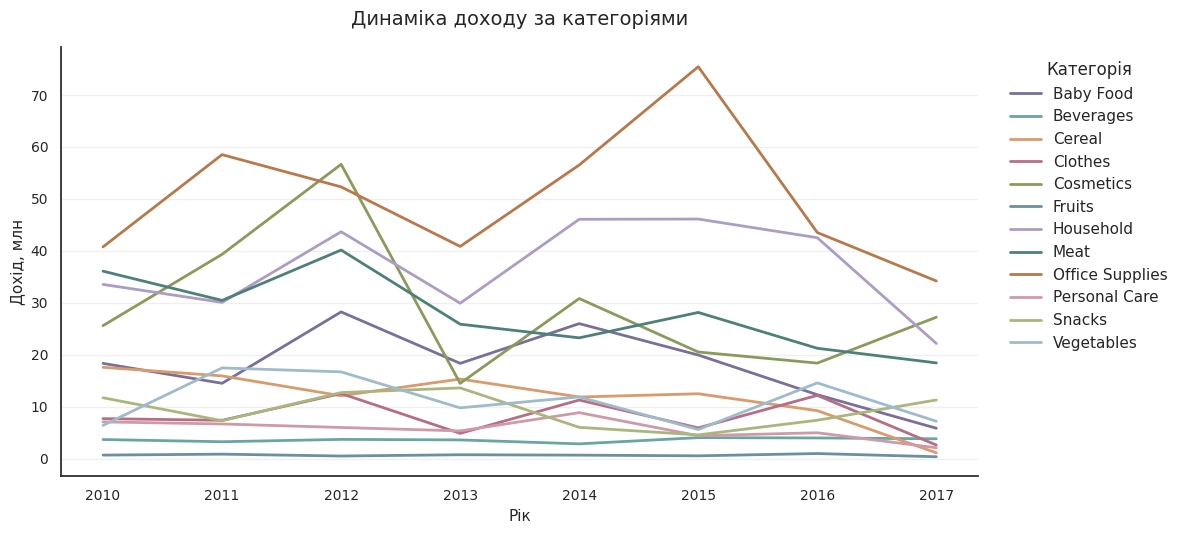

In [412]:
plt.figure(figsize=(12, 5.5))
sns.lineplot(data=category_trend, x="order_year", y="revenue", hue="item_type", linewidth=2)
plt.title('Динаміка доходу за категоріями', fontsize=14, pad=16)
plt.xlabel('Рік')
plt.ylabel('Дохід, млн')
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda value, _: f"{value / 1_000_000:g}"))
plt.legend(title='Категорія', bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


Дохід категорій змінювався нерівномірно. Помітний пік **Office Supplies у 2015 році**. Значні суми також дають Household, Cosmetics і Meat.


### 7.2. Дохід у топ-5 країнах

Обираю п’ять країн за загальним доходом і порівнюю їхні річні суми.


In [413]:
top_countries = sales_data.groupby("country_name")["revenue"].sum().sort_values(ascending=False).head(5).index

In [414]:
country_trend = sales_data[sales_data["country_name"].isin(top_countries)].groupby(["order_year", "country_name"])["revenue"].sum().reset_index()

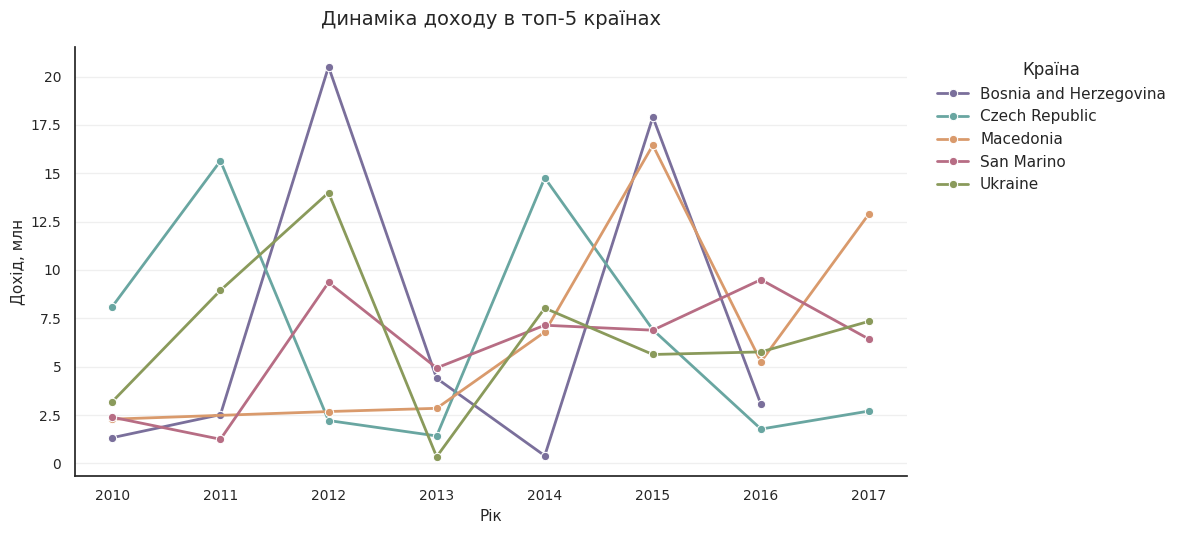

In [415]:
plt.figure(figsize=(12, 5.5))
sns.lineplot(data=country_trend, x="order_year", y="revenue", hue="country_name", marker="o", linewidth=2)
plt.title('Динаміка доходу в топ-5 країнах', fontsize=14, pad=16)
plt.xlabel('Рік')
plt.ylabel('Дохід, млн')
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda value, _: f"{value / 1_000_000:g}"))
plt.legend(title='Країна', bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


У п’яти країнах із найбільшим загальним доходом суми за роками коливаються. Лідер окремого року змінюється.


### 7.3. Дохід за регіонами


In [416]:
region_trend = sales_data.groupby(["order_year", "region"])["revenue"].sum().reset_index()

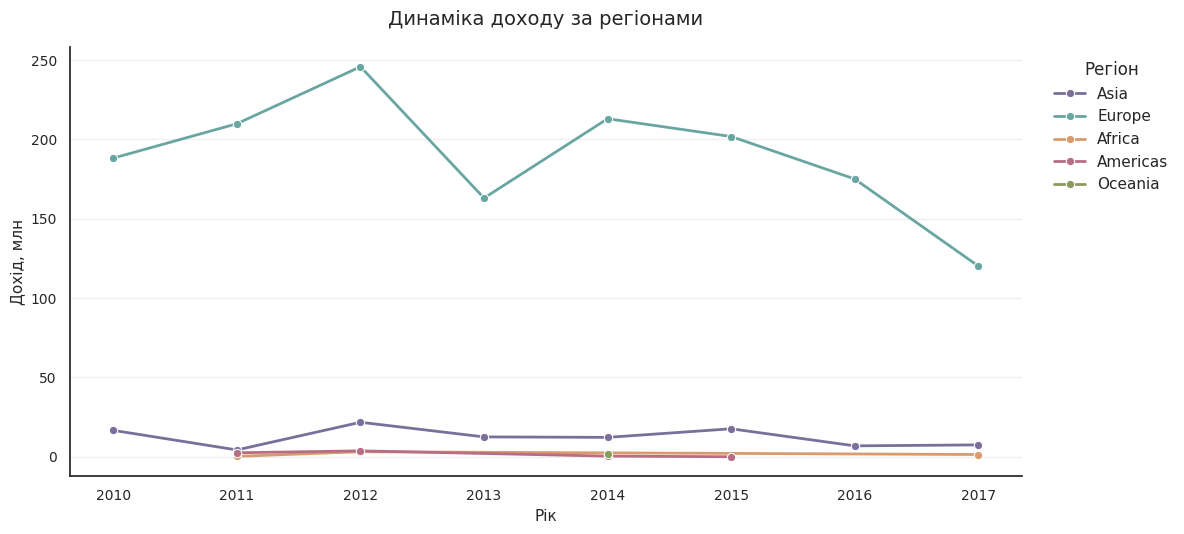

In [417]:
plt.figure(figsize=(12, 5.5))
region_trend = sales_data.groupby(["order_year", "region"])["revenue"].sum().reset_index()
sns.lineplot(data=region_trend, x="order_year", y="revenue", hue="region", marker="o", linewidth=2)
plt.title('Динаміка доходу за регіонами', fontsize=14, pad=16)
plt.xlabel('Рік')
plt.ylabel('Дохід, млн')
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda value, _: f"{value / 1_000_000:g}"))
plt.legend(title='Регіон', bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


**Europe** має найбільший дохід у кожному представленому році, з найвищим значенням у **2012 році**. Нижчу суму за 2017 рік слід читати з урахуванням неповного року.


### 7.4. Продані одиниці за днями тижня

Для п’яти найпопулярніших категорій підсумовую продані одиниці за кожним днем тижня за весь період.


In [418]:
sales_data["day_of_week"] = sales_data["order_date"].dt.day_name()

In [419]:
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
sales_data["day_of_week"] = pd.Categorical(sales_data["day_of_week"], categories=day_order, ordered=True)

In [420]:
weekly_sales = sales_data.groupby(["day_of_week", "item_type"])["units_sold"].sum().reset_index()

/tmp/ipykernel_508/3863384768.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  weekly_sales = sales_data.groupby(["day_of_week", "item_type"])["units_sold"].sum().reset_index()


In [421]:
top_categories = sales_data.groupby("item_type")["units_sold"].sum().sort_values(ascending=False).head(5).index
weekly_sales_top = weekly_sales[weekly_sales["item_type"].isin(top_categories)]

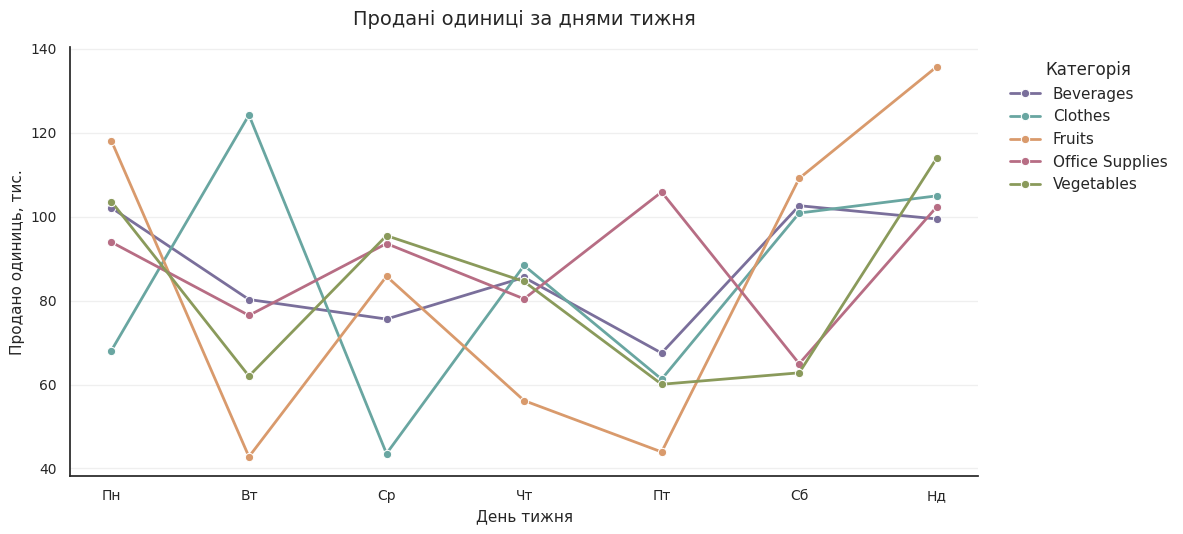

In [422]:
plt.figure(figsize=(12, 5.5))
sns.lineplot(data=weekly_sales_top, x="day_of_week", y="units_sold", hue="item_type", marker="o", linewidth=2)
plt.title('Продані одиниці за днями тижня', fontsize=14, pad=16)
plt.xlabel('День тижня')
plt.ylabel('Продано одиниць, тис.')
plt.xticks(range(7), ["Пн", "Вт", "Ср", "Чт", "Пт", "Сб", "Нд"])
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda value, _: f"{value / 1_000:g}"))
plt.legend(title='Категорія', bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


Розподіл за днями відрізняється між категоріями. **Fruits** має найбільшу кількість проданих одиниць у неділю, **Clothes** — у вівторок, **Office Supplies** — у п’ятницю. Це суми за весь період.


## 8. Висновки


Переглянув і підготував три таблиці, об’єднав їх та проаналізував продажі, прибуток і час до відправлення.

- У робочій таблиці **1 328 замовлень**, розрахований прибуток становить **501,43 млн**.
- **Office Supplies** лідирує за доходом і кількістю проданих одиниць, **Cosmetics** — за прибутком.
- У підготовлених даних найбільші фінансові показники має **Europe**.
- Кількість замовлень Online та Offline майже однакова; фінансові показники Offline трохи вищі.
- Медіанний час до відправлення відрізняється між категоріями й регіонами. На точковому графіку не видно чіткого зв’язку цього часу з прибутком.
- Продажі змінюються за роками й днями тижня. За **2017 рік** є дані лише до 23 липня, тому його загальна сума нижча також через коротший період.